# Laboratorium 1 (dzienne)
## Część 1
Wynik komendy --list:

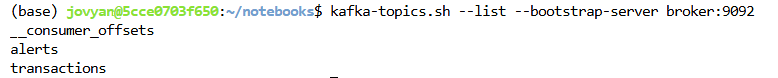

(stworzone takie, bo wcześniej robiłam wersję z zaocznych)

## Część 2
### Zadanie 2.1
Utwórz plik producer.py, który wysyła symulowane transakcje e-commerce do tematu transactions.

Każda transakcja to JSON z polami: - tx_id (np. “TX0001”) - user_id (losowy z “u01” do “u20”) - amount (losowy float 5.0–5000.0) - store (losowy z: “Warszawa”, “Kraków”, “Gdańsk”, “Wrocław”) - category (losowy z: “elektronika”, “odzież”, “żywność”, “książki”) - timestamp (aktualny czas ISO)

Wysyłaj jedną transakcję na sekundę.

Po utworzeniu:

Uruchom producenta w terminalu JupyterLab: python producer.py

Pozostaw działającego i przejdź do następnego zadania.

In [1]:
%%file producer.py
from kafka import KafkaProducer
import json, random, time
from datetime import datetime

producer = KafkaProducer(
    bootstrap_servers='broker:9092',
    value_serializer=lambda v: json.dumps(v).encode('utf-8')
)

sklepy = ["Warszawa", "Kraków", "Gdańsk", "Wrocław"]
kategorie = ["elektronika", "odzież", "żywność", "książki"]

def generate_transaction():
    tx_id = f"TX{random.randint(1000, 9999)}"
    user_id = f"u{random.randint(1, 20):02d}"
    amount = round(random.uniform(5.0, 5000.0), 2)
    store = random.choice(sklepy)
    category = random.choice(kategorie)
    timestamp = datetime.now().isoformat()
    
    return {
        'tx_id': tx_id,
        'user_id': user_id,
        'amount': amount,
        'store': store,
        'category': category,
        'timestamp': timestamp
    }

i = 0

try:
    while True:
        i += 1
        tx = generate_transaction()
        producer.send('transactions', value=tx)
        print(f"[{i}] {tx['tx_id']} | {tx['amount']:.2f} PLN | {tx['store']}")        
        time.sleep(1)
        
except KeyboardInterrupt:
    print(" Zatrzymywanie producenta...")

finally:
    producer.flush()
    producer.close()

Writing producer.py


## Część 3 - konsument bezstanowy
### Zadanie 3.1
Napisz konsumenta, który czyta z transactions i wyświetla tylko transakcje z amount > 3000.

In [2]:
%%file consumer_filter.py
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

print("Nasłuchuję na duże transakcje (amount > 3000)...")

for message in consumer:
    tx = message.value
    if tx['amount'] > 3000:
        print(f"ALERT: {tx['tx_id']} | {tx['amount']:.2f} PLN | {tx['store']} | {tx['category']}")

Writing consumer_filter.py


### Zadanie 3.2
Napisz konsumenta, który do słownika eventu dodaje pole risk_level: - amount > 3000 → “HIGH” - amount > 1000 → “MEDIUM” - pozostałe → “LOW”

In [3]:
%%file consumer_enrich.py
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    group_id='enrichment-group',
    auto_offset_reset='earliest',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

print("Uruchomiono wzbogacanie transakcji o poziom ryzyka...")

for message in consumer:
    tx = message.value
    
    if tx['amount'] > 3000:
        tx['risk_level'] = 'HIGH'
    elif tx['amount'] > 1000:
        tx['risk_level'] = 'MEDIUM'
    else:
        tx['risk_level'] = 'LOW'
    
    print(f"ID: {tx['tx_id']} | Kwota: {tx['amount']:8.2f} | RYZYKO: {tx['risk_level']}")

Writing consumer_enrich.py


## Część 4 - konsument stanowy
### Zadanie 4.1
Napisz konsumenta, który prowadzi bieżące zliczanie transakcji per sklep i wypisuje podsumowanie co 10 wiadomości.

In [4]:
%%file consumer_count.py
from kafka import KafkaConsumer
from collections import Counter, defaultdict
import json

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    auto_offset_reset='earliest',
    group_id='count-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

store_counts = Counter()
total_amount = defaultdict(float)
msg_count = 0

for message in consumer:
    store = message.value['store']
    amount = message.value['amount']

    store_counts[store] += 1
    total_amount[store] += amount
    msg_count += 1

    if msg_count % 10 == 0:
        print(f"\n--- PODSUMOWANIE (po {msg_count} wiadomościach) ---")
        print(f"{'Sklep':<12} | {'Liczba':<7} | {'Suma':<10} | {'Średnia':<8}")
        print("-" * 50)
        
        for s in sorted(store_counts.keys()):
            count = store_counts[s]
            total = total_amount[s]
            avg = total / count if count > 0 else 0
            print(f"{s:<12} | {count:<7} | {total:>10.2f} | {avg:>8.2f}")
        print("-" * 50)

Writing consumer_count.py


### Zadanie 4.2
Napisz konsumenta, który śledzi per kategoria: - liczbę transakcji - łączny przychód - min i max kwotę

Wypisuj co 10 wiadomości.

In [5]:
%%file consumer_stats.py
from kafka import KafkaConsumer
import json

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    auto_offset_reset='earliest',
    group_id='stats-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

stats = {}
msg_count = 0

print("Analizuję statystyki kategorii...")

for message in consumer:
    tx = message.value
    cat = tx['category']
    amt = tx['amount']

    if cat not in stats:
        stats[cat] = {
            'count': 0,
            'total': 0.0,
            'min': amt,
            'max': amt
        }

    s = stats[cat]
    s['count'] += 1
    s['total'] += amt
    s['min'] = min(s['min'], amt)
    s['max'] = max(s['max'], amt)
    
    msg_count += 1

    if msg_count % 10 == 0:
        print(f"\n=== STATYSTYKI KATEGORII (po {msg_count} tx) ===")
        print(f"{'Kategoria':<15} | {'Liczba':<6} | {'Suma':<10} | {'Min':<8} | {'Max':<8}")
        print("-" * 60)
        
        for c in sorted(stats.keys()):
            v = stats[c]
            print(f"{c:<15} | {v['count']:<6} | {v['total']:>10.2f} | {v['min']:>8.2f} | {v['max']:>8.2f}")

Writing consumer_stats.py


## Część 5
### Zadanie 5.1

Otwórz 3 terminale w JupyterLab: 1. python producer.py 2. python consumer_filter.py 3. python consumer_count.py

### Zadanie 5.2
**1. Co się stanie, jeśli uruchomisz consumer_filter.py po zakończeniu producenta?**

To zależy od jednego parametru w kodzie: auto_offset_reset.

W moim kodzie go nie użyłam, więc konsument będzie czekał tylko na nowe wiadomości. Ponieważ producent nie jest już uruchomiony, konsument nic się nie wyświetli. (tak samo byłoby gdyby auto_offset_reset = 'latest')

Gdyby auto_offset_reset = 'earliest', to konsument po uruchomieniu "cofnie się w czasie". Przeczyta wszystkie transakcje, które producent zdążył wysłać wcześniej, przefiltruje te powyżej 3000 PLN i wyświetli je na ekranie.

**2. Co się stanie, jeśli dwóch konsumentów ma TĘ SAMĄ group_id?**

W architekturze Kafki konsumenci o tym samym group_id tworzą tzw. grupę konsumencką (consumer group). W takim przypadku zachodzi proces równoważenia obciążenia (load balancing). Kafka dzieli strumień danych między te dwa procesy. Każda wiadomość (pochodząca z danej partycji) zostanie dostarczona tylko do jednego z tych konsumentów.

W praktyce oznacza to, że żaden z terminali nie pokaże kompletu wyników — część transakcji trafi do pierwszego okna, a reszta do drugiego.

**3. Jaka jest różnica między przetwarzaniem bezstanowym a stanowym?**

***Przetwarzanie bezstanowe***: Każda wiadomość jest przetwarzana w pełnej izolacji od pozostałych. Decyzja podejmowana przez program zależy wyłącznie od treści aktualnie odczytanego zdarzenia.

***Przetwarzanie stanowe***: Program musi zachowywać i aktualizować informacje (tzw. stan) pomiędzy kolejnymi zdarzeniami. Wynik przetwarzania zależy nie tylko od obecnej wiadomości, ale też od historii poprzednich.


## Praca domowa
1. Napisz konsumenta wykrywającego anomalie prędkości: alert jeśli ten sam user_id wykona więcej niż 3 transakcje w ciągu 60 sekund.
2. Wypchnij kod do repozytorium Git.

In [6]:
%%file anomaly_detector.py
from kafka import KafkaConsumer
import json
from collections import defaultdict
from datetime import datetime

consumer = KafkaConsumer(
    'transactions',
    bootstrap_servers='broker:9092',
    auto_offset_reset='latest',  # anomalie tylko w czasie rzeczywistym
    group_id='anomaly-detector-group',
    value_deserializer=lambda x: json.loads(x.decode('utf-8'))
)

# Słownik przechowujący listy timestampów dla każdego użytkownika
user_history = defaultdict(list)

print("System wykrywania anomalii prędkości uruchomiony...")
print("Monitorowanie: > 3 transakcje w ciągu 60 sekund na użytkownika")

for message in consumer:
    tx = message.value
    user_id = tx['user_id']

    current_time = datetime.fromisoformat(tx['timestamp'])
    
    user_history[user_id].append(current_time)
    
    user_history[user_id] = [
        t for t in user_history[user_id] 
        if (current_time - t).total_seconds() <= 60
    ]
    
    if len(user_history[user_id]) > 3:
        print(f"!!! ALERT ANOMALII !!!")
        print(f"Użytkownik: {user_id} wykonał {len(user_history[user_id])} transakcje w ciągu ostatniej minuty!")
        print(f"Ostatnia transakcja: {tx['tx_id']} o godzinie {current_time.strftime('%H:%M:%S')}")
        print("-" * 30)

Writing anomaly_detector.py
